
# PART 1




# Framing & Data Familiarity

**Executive Question:** *What pricing strategy should Allianz use for different U.S. customer segments to be fair and profitable?*

**Hypotheses (to be tested):**
- H1: Smoking significantly increases medical annual_medical_cost.
- H2: Higher BMI leads to higher medical annual_medical_cost.
- H3: Age is positively correlated with annual_medical_cost.
- H4: Individuals with chronic diseases have higher annual medical costs.
- H5: Individuals with more hospitalizations over the past 3 years have higher annual medical costs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:

# Load data
df = pd.read_csv(r"C:\Users\sruth\Documents\Greenbootcamps\Med_Insurance_Finalproject\Data\medical_insurance.csv")
df.head()


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


## 1. Structure: columns, types, sample rows

In [3]:

# Overview
print("Shape:", df.shape)
display(df.dtypes)

Shape: (100000, 54)


person_id                        int64
age                              int64
sex                             object
region                          object
urban_rural                     object
income                         float64
education                       object
marital_status                  object
employment_status               object
household_size                   int64
dependents                       int64
bmi                            float64
smoker                          object
alcohol_freq                    object
visits_last_year                 int64
hospitalizations_last_3yrs       int64
days_hospitalized_last_3yrs      int64
medication_count                 int64
systolic_bp                    float64
diastolic_bp                   float64
ldl                            float64
hba1c                          float64
plan_type                       object
network_tier                    object
deductible                       int64
copay                    

## 2. Data Quality: missing values, duplicates, basic sanity checks

In [4]:

# Missing values & duplicates
missing = df.isna().sum().sort_values(ascending=False)
dupes = df.duplicated().sum()
print("Missing values per column:\n", missing, "\n")
print("Duplicate rows:", dupes)


Missing values per column:
 alcohol_freq                   30083
person_id                          0
sex                                0
region                             0
urban_rural                        0
age                                0
income                             0
education                          0
employment_status                  0
marital_status                     0
household_size                     0
dependents                         0
bmi                                0
smoker                             0
visits_last_year                   0
hospitalizations_last_3yrs         0
days_hospitalized_last_3yrs        0
medication_count                   0
systolic_bp                        0
diastolic_bp                       0
ldl                                0
hba1c                              0
plan_type                          0
network_tier                       0
deductible                         0
copay                              0
policy_ter

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  object 
 3   region                       100000 non-null  object 
 4   urban_rural                  100000 non-null  object 
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  object 
 7   marital_status               100000 non-null  object 
 8   employment_status            100000 non-null  object 
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  object 
 13  

In [6]:
df['alcohol_freq'].value_counts(dropna=False) #dropna=False → ensures that missing values (NaN) are also counted and shown in the output.

alcohol_freq
Occasional    45078
NaN           30083
Weekly        19833
Daily          5006
Name: count, dtype: int64

In [7]:
df['alcohol_freq'].isna().mean() * 100 #what % of rows are missing

np.float64(30.083)

In [8]:
df['alcohol_freq'] = df['alcohol_freq'].fillna('Unknown') #Filling missing values with "unknown"

In [9]:
df['alcohol_freq'].isna().sum()

np.int64(0)

In [10]:
df.isna().any().sum()

np.int64(0)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.isna().sum().sort_values(ascending=False)

person_id                      0
age                            0
sex                            0
region                         0
urban_rural                    0
income                         0
education                      0
marital_status                 0
employment_status              0
household_size                 0
dependents                     0
bmi                            0
smoker                         0
alcohol_freq                   0
visits_last_year               0
hospitalizations_last_3yrs     0
days_hospitalized_last_3yrs    0
medication_count               0
systolic_bp                    0
diastolic_bp                   0
ldl                            0
hba1c                          0
plan_type                      0
network_tier                   0
deductible                     0
copay                          0
policy_term_years              0
policy_changes_last_2yrs       0
provider_quality               0
risk_score                     0
annual_med

In [13]:
df.columns = df.columns.str.lower()

In [14]:
df.columns = df.columns.str.replace(' ', '_')

In [15]:
df.describe()

,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,50000.500000,47.521500,4.987390e+04,2.430900,0.898380,26.990512,1.92765,0.093640,0.373350,1.236320,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,4.680021e+04,1.075126,0.950654,4.994883,1.73773,0.304848,1.373011,1.209358,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,1.100000e+03,1.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,3.620000e+04,2.000000,1.000000,27.000000,2.00000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.00000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000
max,100000.000000,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.00000,3.000000,21.000000,11.000000,...,1.000000,1.000000,1.000000,7.000000,6.000000,7.000000,7.00000,7.000000,1.000000,1.000000


## 3. Distributions & quick visuals 

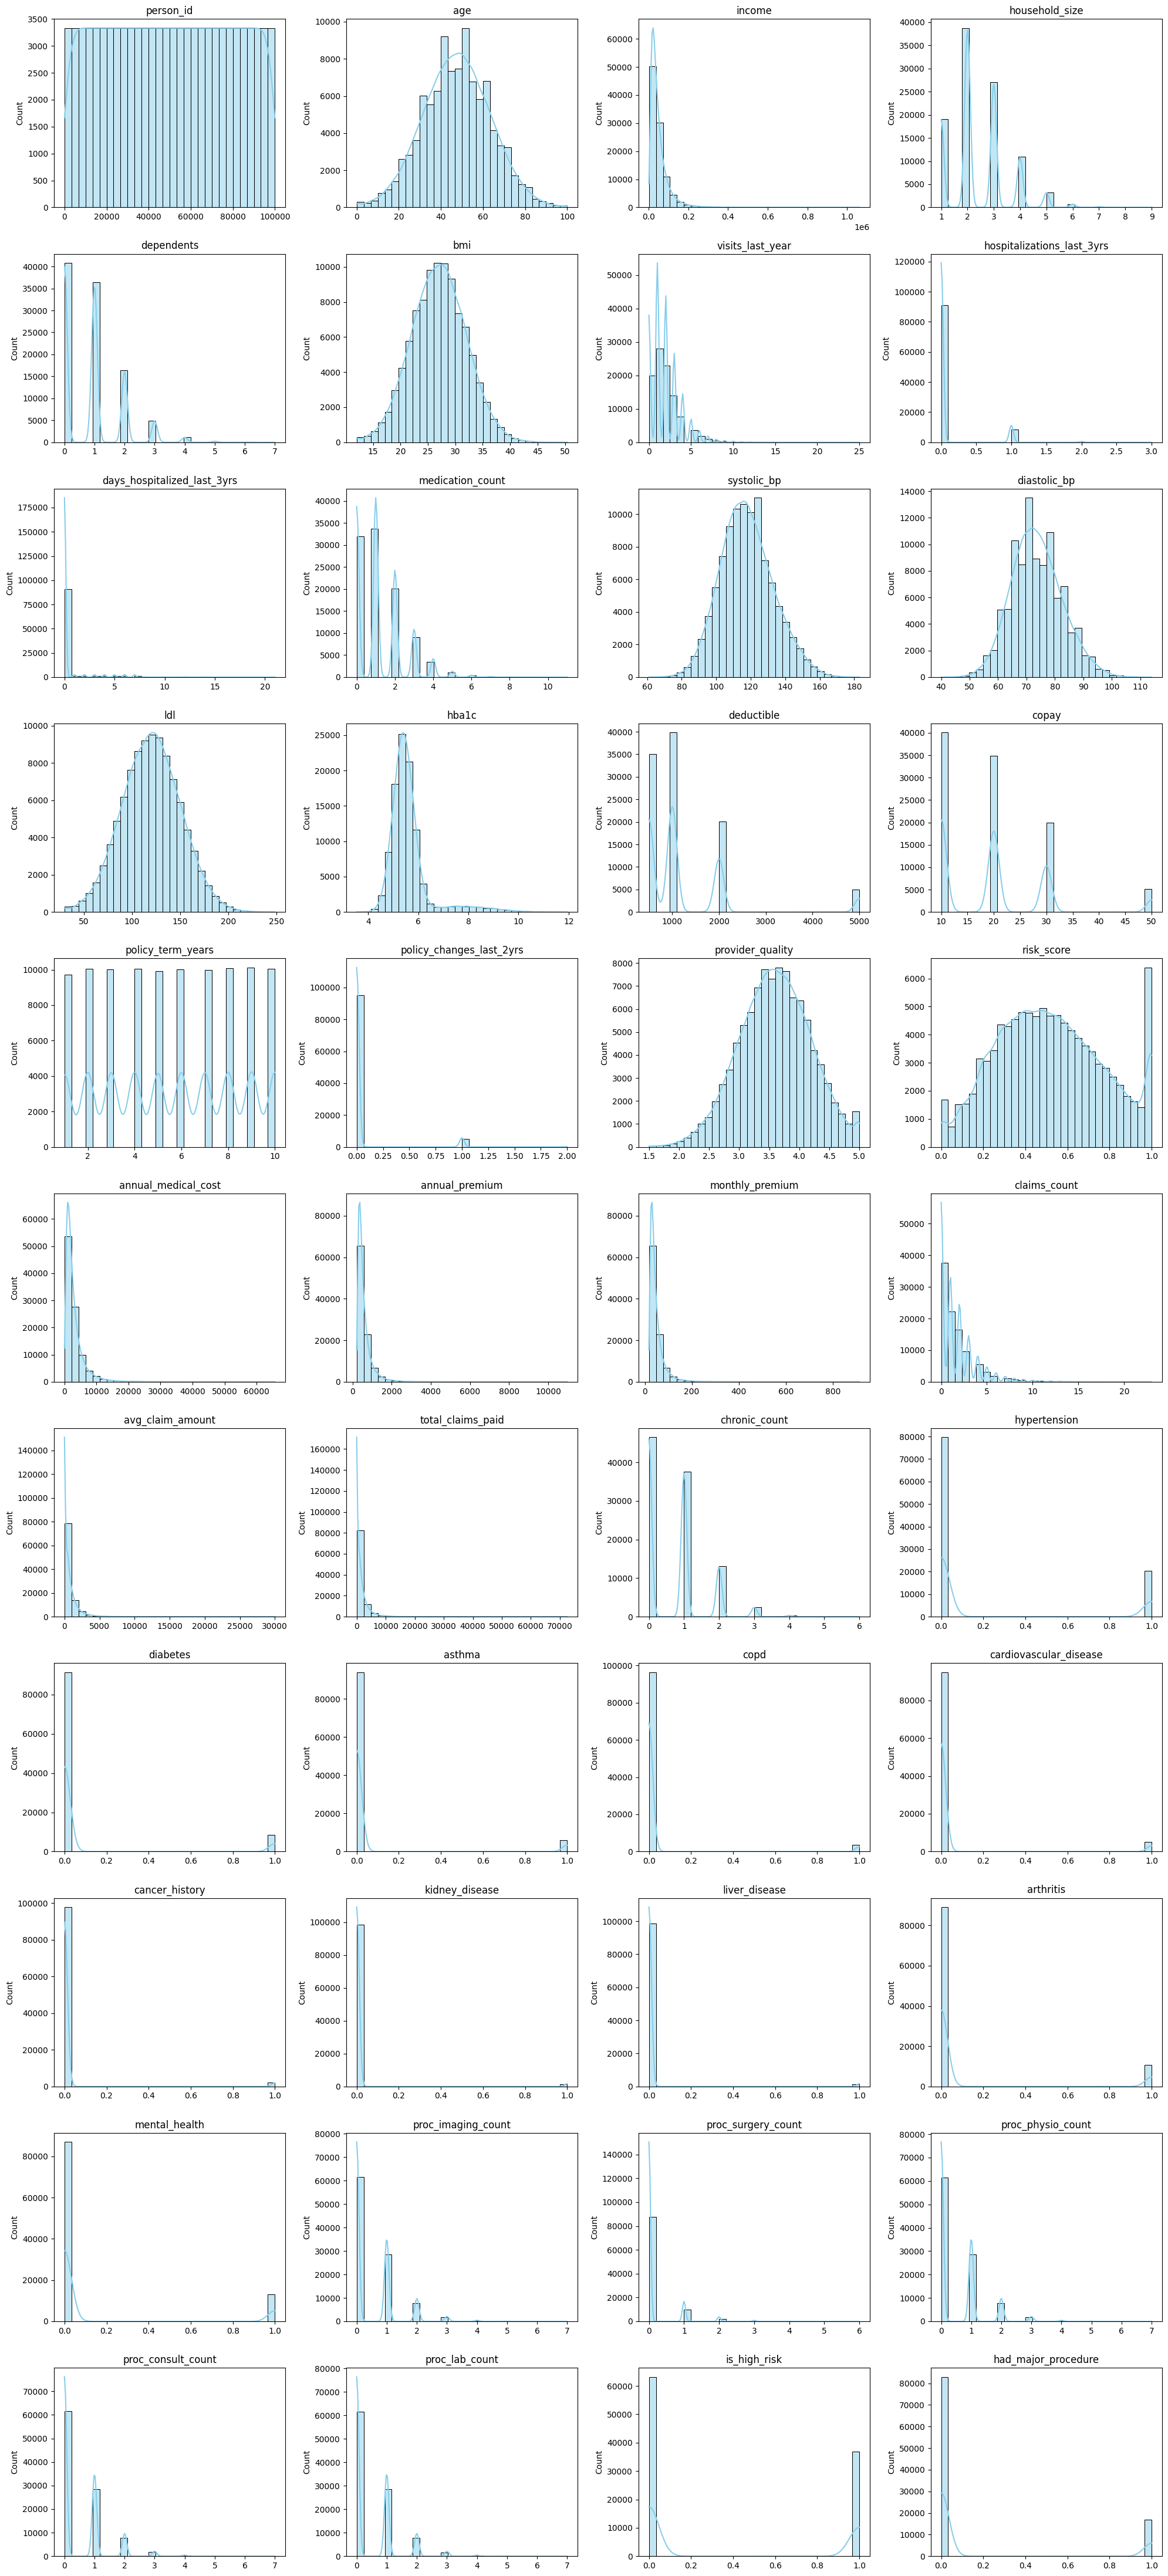

In [16]:

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Select numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Set up subplot grid
n_cols = 4                                 # number of plots per row
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

plt.figure(figsize=(5 * n_cols, 4 * n_rows))  # adjust overall size

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'{col}', fontsize=12)
    plt.xlabel('')
    plt.ylabel('Count')

plt.tight_layout()
plt.show()


C:\Users\sruth\AppData\Local\Temp\ipykernel_7524\3810121996.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel')
C:\Users\sruth\AppData\Local\Temp\ipykernel_7524\3810121996.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel')
C:\Users\sruth\AppData\Local\Temp\ipykernel_7524\3810121996.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel')
C:\Users\sruth\AppData\Local\Temp\ipykernel_7524\3810121996.py:17: FutureWarning: 

Passing `palette

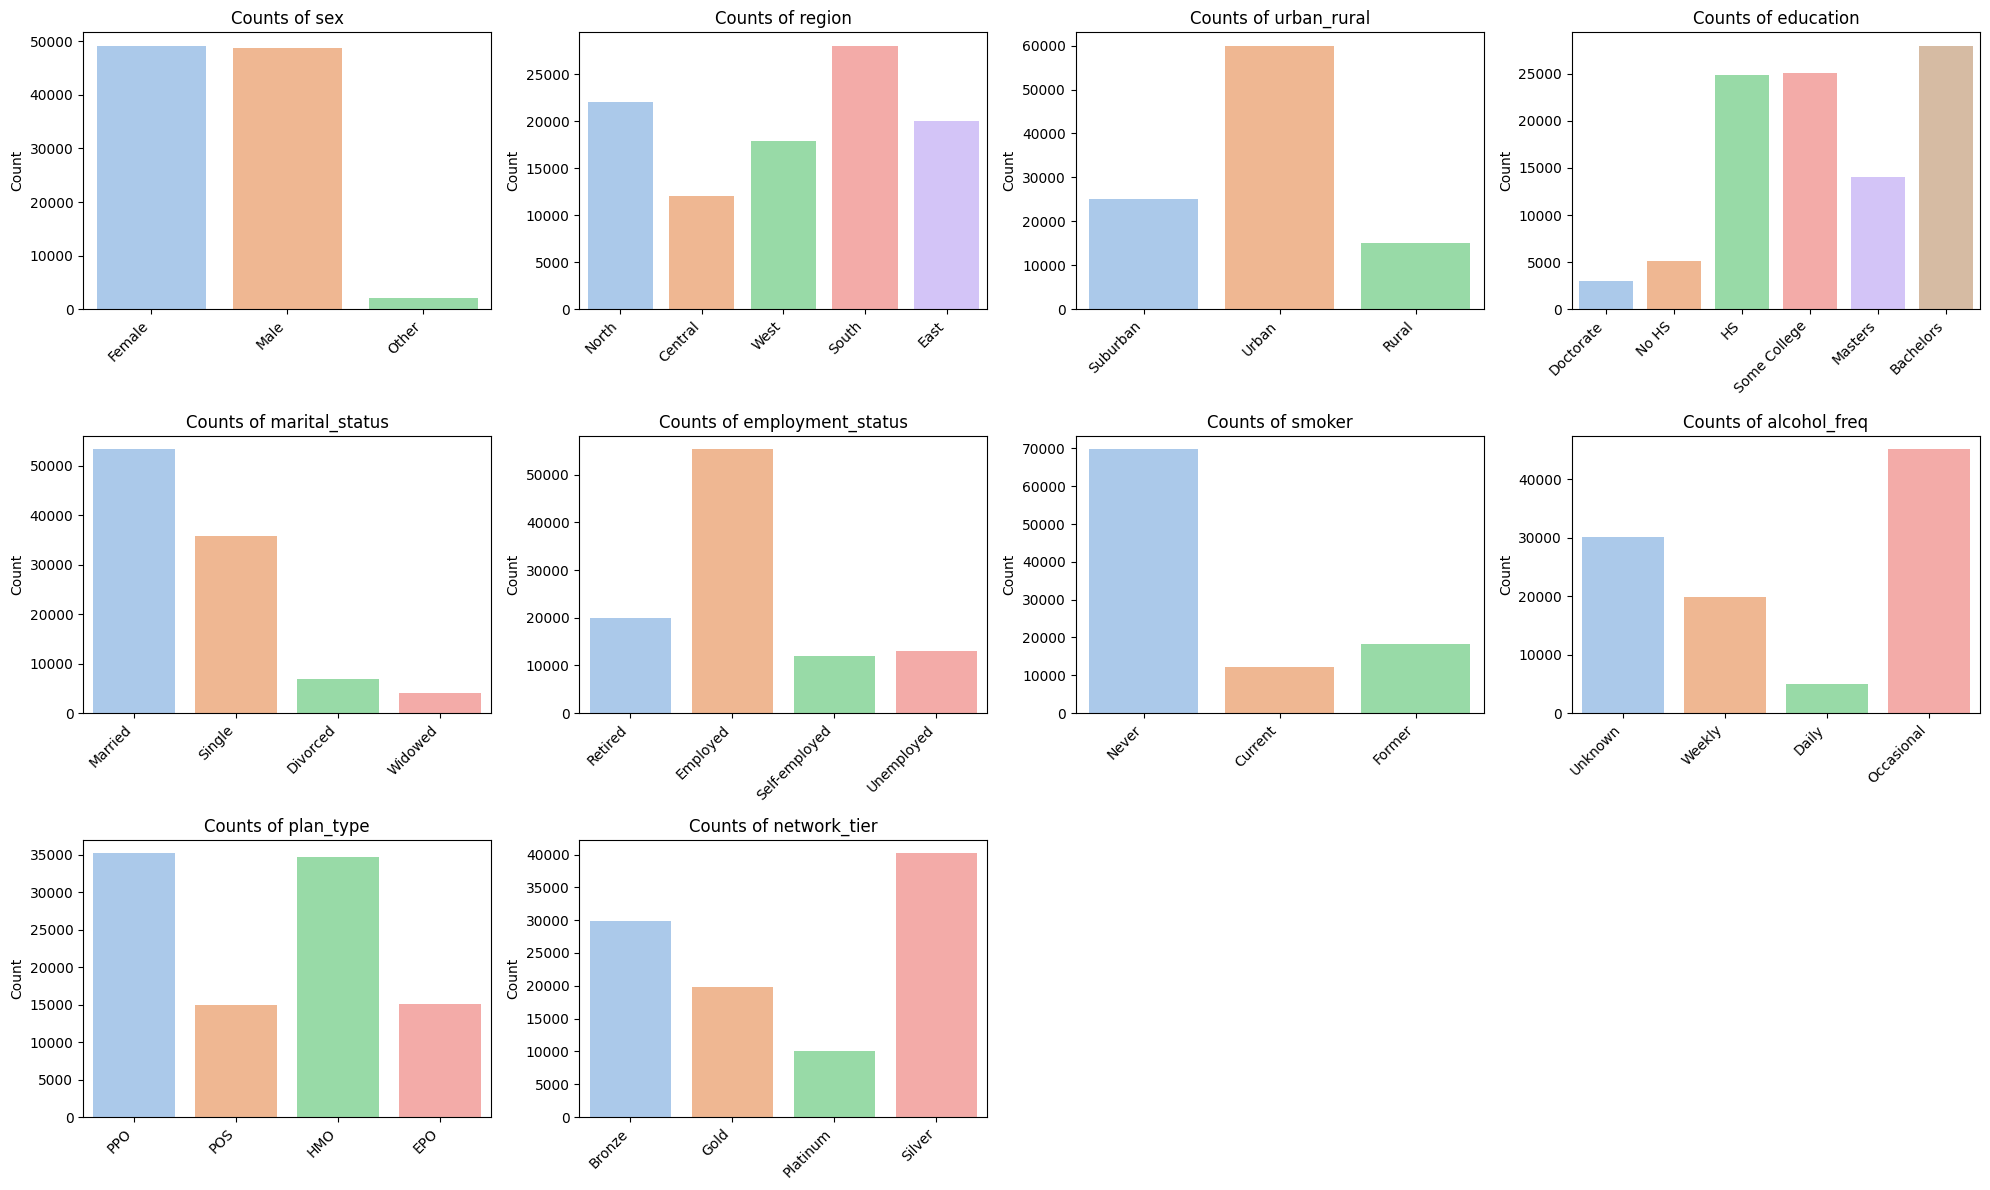

In [17]:

# Categorical counts
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select categorical columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Define grid layout
n_cols = 4                                 # number of charts per row
n_rows = int(np.ceil(len(cat_cols) / n_cols))

plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.countplot(data=df, x=col, palette='pastel')
    plt.title(f'Counts of {col}', fontsize=12)
    plt.xlabel('')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()



## 4. Early cost signals vs key drivers

In [18]:

# Quick pivots for early signals
signals = {}
    
if 'smoker' in df.columns and 'annual_medical_cost' in df.columns:
    # smoker
    signals['smoker'] = df.groupby('smoker')['annual_medical_cost'].mean().sort_values(ascending=False)
   
if 'alcohol_freq' in df.columns and 'annual_medical_cost' in df.columns:
    # alcohol
    signals['alcohol_freq'] = df.groupby('alcohol_freq')['annual_medical_cost'].mean().sort_values(ascending=False)
    
if 'region' in df.columns and 'annual_medical_cost' in df.columns:
    # region
    signals['region'] = df.groupby('region')['annual_medical_cost'].mean().sort_values(ascending=False)

if 'bmi' in df.columns and 'annual_medical_cost' in df.columns:
    # BMI bands
    bins = [0, 18.5, 25, 30, 35, 100]
    labels = ['Underweight','Normal','Overweight','Obese I','Obese II+']
    df['bmi_band'] = pd.cut(df['bmi'], bins=bins, labels=labels, right=False)
    signals['bmi_band'] = df.groupby('bmi_band')['annual_medical_cost'].mean().sort_values(ascending=False)

if 'age' in df.columns and 'annual_medical_cost' in df.columns:
    # Age bands
    bins = [0, 25, 35, 45, 55, 65, 120]
    labels = ['<25','25-34','35-44','45-54','55-64','65+']
    df['age_band'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)
    signals['age_band'] = df.groupby('age_band')['annual_medical_cost'].mean().sort_values(ascending=False)

    
if 'chronic_count' in df.columns and 'annual_medical_cost' in df.columns:
    # Chronic disease count
    signals['chronic_count'] = df.groupby('chronic_count')['annual_medical_cost'].mean().sort_values(ascending=False)

    
if 'hospitalizations_last_3yrs' in df.columns and 'annual_medical_cost' in df.columns:
    # Hospitalizations in last 3 years
    signals['hospitalizations_last_3yrs'] = df.groupby('hospitalizations_last_3yrs')['annual_medical_cost'].mean().sort_values(ascending=False)


for k, v in signals.items():
    print(f"\nAverage charges by {k}:")
    display(v.to_frame('avg_charges'))



Average charges by smoker:


C:\Users\sruth\AppData\Local\Temp\ipykernel_7524\2893492069.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  signals['bmi_band'] = df.groupby('bmi_band')['annual_medical_cost'].mean().sort_values(ascending=False)
C:\Users\sruth\AppData\Local\Temp\ipykernel_7524\2893492069.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  signals['age_band'] = df.groupby('age_band')['annual_medical_cost'].mean().sort_values(ascending=False)


,avg_charges
smoker,
Current,4295.561051
Former,3161.766632
Never,2746.007817



Average charges by alcohol_freq:


,avg_charges
alcohol_freq,
Daily,3056.392715
Unknown,3016.139844
Occasional,3008.221003
Weekly,2990.257019


...

,avg_charges
age_band,
65+,3708.867110
55-64,3286.996217
45-54,3049.624162
35-44,2762.556495
25-34,2569.028065
<25,2333.037220



Average charges by chronic_count:


,avg_charges
chronic_count,
6,18747.810000
4,7320.433196
3,5671.426627
2,4438.189257
5,3885.147778
1,3332.012914
0,2176.331749



Average charges by hospitalizations_last_3yrs:


,avg_charges
hospitalizations_last_3yrs,
3,9606.951250
2,7415.814749
1,4919.633652
0,2810.443094


In [19]:
df['chronic_count'].value_counts()

chronic_count
0    46532
1    37579
2    13111
3     2452
4      316
5        9
6        1
Name: count, dtype: int64

C:\Users\sruth\AppData\Local\Temp\ipykernel_7524\2481034836.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=chronic_summary, x='chronic_count', y='mean', palette='viridis')


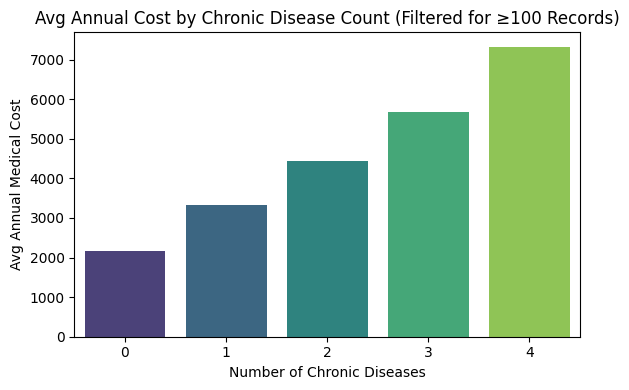

In [20]:
# Compute group averages with counts
chronic_summary = (
    df.groupby('chronic_count')['annual_medical_cost']
    .agg(['mean', 'count'])
    .reset_index()
)

# Filter out very small groups (less than 100 samples)
chronic_summary = chronic_summary[chronic_summary['count'] >= 100]

# Plot
plt.figure(figsize=(6,4))
sns.barplot(data=chronic_summary, x='chronic_count', y='mean', palette='viridis')
plt.title("Avg Annual Cost by Chronic Disease Count (Filtered for ≥100 Records)")
plt.xlabel("Number of Chronic Diseases")
plt.ylabel("Avg Annual Medical Cost")
plt.tight_layout()
plt.show()



## 5.  Observations

- Data shape & types:
  Dataset contains 100,000 rows × 54 columns with a mix of numeric (age, BMI, costs, vitals) and categorical (sex, region, smoker, diseases) variables.
  
  All column types are appropriate for analysis (mostly int64, float64, and object).

- Missing values / duplicates:

  Minimal missingness overall.

  alcohol_freq had ~30% missing → filled with "Unknown".

  No duplicate rows detected.

- Distribution quirks (skewed charges? outliers?):

  Most cost-related and count variables (annual_medical_cost, avg_claim_amount, total_claims_paid, claims_count, visits_last_year) show strong right skew, indicating that a small portion of customers drive the majority of expenses.

  Financial features like income, deductible, and copay also exhibit long right tails, suggesting a few high-income or high-coverage individuals.

  Health indicators such as BMI, blood pressure, LDL, and HbA1c appear roughly normal, confirming a representative health distribution in the population.

  Chronic disease indicators (diabetes, hypertension, etc.) are binary and heavily imbalanced — most people are healthy, with a small fraction having chronic conditions.

  A few extreme outliers exist in income, days_hospitalized_last_3yrs, and annual_medical_cost, likely high-risk or complex medical cases.

- Early Cost Signals (smoker, BMI, age, chronic diseases, hospitalizations) 
 

  Smokers have the highest average annual medical cost (~2.5–3× higher than non-smokers).

  BMI bands show a steady rise in cost from “Normal” → “Obese II+,” confirming the link between obesity and higher healthcare spending.

  Older adults (45–65+) incur substantially higher medical expenses than younger groups.

  Chronic disease count: Average annual medical cost increases sharply as the number of chronic conditions rises. Patients with 3–4 chronic diseases cost nearly 3× more than those with none.

  Hospitalizations (past 3 years): Individuals with frequent hospital stays show a consistent, near-linear increase in medical costs — indicating hospitalization frequency is a strong early signal of high-cost risk.


In [21]:
# ✅ Export cleaned dataset to CSV for Day 2 use
df.to_csv(r"C:\Users\sruth\Documents\Greenbootcamps\Med_Insurance_Finalproject\Data\medical_insurance_clean.csv", index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
